In [51]:
import pandas as pd
import numpy as np

In [52]:
sov = pd.read_excel("England_Flood_SOV_100_Locations.xlsx", sheet_name="SOV_100")

In [53]:
sov.head()

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,BI_TIV,Total_TIV,Reported_Total_TIV,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct
0,LOC001,B001,Bath AI/R&D Office 001,AI/R&D Office,8 Mill Way,Bath,Somerset,BA30 9WA,Medium,Rivers & Sea,...,4800000,20950000,20950000,OK,75,Central,No,Central,No,22.91
1,LOC002,B002,Colchester Call Centre 002,Call Centre,92 Innovation Estate,Colchester,Essex,CO34 1RU,High,Rivers & Sea,...,2700000,17650000,17650000,OK,50,Local,Yes,None,No,15.30
2,LOC003,B003,Kingston upon Hull Data Centre 003,Data Centre,26 Technology Drive,Kingston upon Hull,East Riding of Yorkshire,HU59 6FM,High,Rivers & Sea + Surface Water,...,25000000,75000000,72000000,ERROR,100,Central,No,None,No,33.33
3,LOC004,B004,Bristol Operations Centre 004,Operations Centre,84 Quayside Way,Bristol,Bristol,BS5 6NJ,Medium,Rivers & Sea + Surface Water,...,4850000,19850000,19850000,OK,100,Central,No,Central,No,24.43
4,LOC005,B005,Kingston upon Hull Call Centre 005,Call Centre,103 Innovation Way,Kingston upon Hull,East Riding of Yorkshire,HU18 9SC,High,Rivers & Sea + Surface Water,...,4750000,17350000,17350000,OK,25,Central,Yes,None,No,27.38


In [54]:
sov.shape

(100, 27)

In [55]:
sov.columns.tolist()

['Location_ID',
 'Building_ID',
 'Building_Name',
 'Occupancy',
 'Address',
 'City',
 'County',
 'Postcode',
 'Flood_Risk_Band',
 'Primary_Flood_Source',
 'Stories',
 'Floor_Area_sqft',
 'Year_Built',
 'Construction_Code',
 'Building_TIV',
 'Contents_TIV',
 'EDP_IT_TIV',
 'BI_TIV',
 'Total_TIV',
 'Reported_Total_TIV',
 'TIV_Check',
 'Sprinkler_Coverage_Pct',
 'Fire_Detection',
 'Smoke_Detection',
 'Burglar_Alarm',
 'Vacant',
 'BI_Share_of_TIV_Pct']

### 1. How many locations/rows are in the portfolio?

There are 100 rows and 27 columns in the excel file. Each record represents a portfolio location, subject to validation of unique Location ID values.

### 2. What variables do we have?

There are 27 different variables in the SOV such as Location ID, Building Name, Occupancy, Total TIV and so on.

#### 2.1 Adding Currency Column

In [217]:
sov["Currency"]="Great British Pound"

### 3. Which variables are critical for exposure/risk analysis?

Key variables for exposure and risk analysis include location/geography, TIV components, occupancy, construction, flood-risk classification and primary flood source. Secondary modifiers such as fire sprinklers and alarms provide additional information for risk assessment.

In [56]:
sov["Location_ID"].nunique()

98

### 4. Are there any duplicate locations?

As the total number of unique records are 98, we may some duplicate locations in the dataset.

In [57]:
dup_records=sov[sov.duplicated(subset=["Location_ID"],keep=False)]
dup_records

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,BI_TIV,Total_TIV,Reported_Total_TIV,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct
9,LOC010,B010,Leeds Equipment Warehouse 010,Equipment Warehouse,109 Parkside Court,Leeds,West Yorkshire,LS94 1YX,Medium,Surface Water,...,1550000,20000000,20000000,OK,50,Central,No,None,No,7.75
24,LOC025,B025,Preston Corporate Office 025,Corporate Office,181 Bridge Industrial Estate,Preston,Lancashire,PR54 7LU,Medium,Rivers & Sea,...,1450000,14100000,14100000,OK,75,Local,Yes,Central,No,10.28
97,LOC010,B098,Peterborough AI/R&D Office 098,AI/R&D Office,132 Enterprise Industrial Estate,Peterborough,Cambridgeshire,PE52 2FE,Medium,Surface Water,...,7000000,29900000,29900000,OK,50,Local,Yes,Central,No,23.41
98,LOC025,B099,Coventry Equipment Warehouse 099,Equipment Warehouse,120 Meadow Road,Coventry,West Midlands,CV52 9ZK,High,Rivers & Sea,...,5150000,28400000,28400000,OK,90,None,No,Local,No,18.13


We found 2 IDs occur twice.

#### 4.1 Investigating the duplicate IDs

In [58]:
dup_records[["Location_ID", "Building_ID", "Building_Name",
             "Address", "City", "Postcode", "Occupancy", "Total_TIV"]]

,Location_ID,Building_ID,Building_Name,Address,City,Postcode,Occupancy,Total_TIV
9,LOC010,B010,Leeds Equipment Warehouse 010,109 Parkside Court,Leeds,LS94 1YX,Equipment Warehouse,20000000
24,LOC025,B025,Preston Corporate Office 025,181 Bridge Industrial Estate,Preston,PR54 7LU,Corporate Office,14100000
97,LOC010,B098,Peterborough AI/R&D Office 098,132 Enterprise Industrial Estate,Peterborough,PE52 2FE,AI/R&D Office,29900000
98,LOC025,B099,Coventry Equipment Warehouse 099,120 Meadow Road,Coventry,CV52 9ZK,Equipment Warehouse,28400000


The duplicated records are isolated and compared across key columns, including Building ID, Building Name, Address, City, Postcode, Occupancy, and Total TIV.

#### 4.2 Are these duplicate IDs or duplicate locations?

The investigation shows that the repeated Location IDs do not represent duplicate physical locations.

1. LOC010 is assigned to properties in Leeds and Peterborough, with different addresses, postcodes, occupancies and TIVs.
2. LOC025 is assigned to properties in Preston and Coventry, again with different property and exposure characteristics.

Hence, Location ID has been incorrectly assigned to distinctly unique locations.

#### 4.3 Data Remediation

The duplicated identifiers will be corrected using the corresponding Building_ID sequence.

In [59]:
sov.loc[97,"Location_ID"]="LOC098"
sov.loc[98,"Location_ID"]="LOC099"

In [60]:
sov["Location_ID"].nunique()

100

Achieved result: 100 SOV records with 100 unique Location IDs.

### 5. Check for missing values 

In [159]:
sov.isna().sum()

Location_ID               0
Building_ID               0
Building_Name             0
Occupancy                 0
Address                   0
City                      0
County                    0
Postcode                  0
Flood_Risk_Band           0
Primary_Flood_Source      0
Stories                   0
Floor_Area_sqft           0
Year_Built                1
Construction_Code         1
Building_TIV              0
Contents_TIV              0
EDP_IT_TIV                0
BI_TIV                    0
Total_TIV                 0
Reported_Total_TIV        0
TIV_Check                 0
Sprinkler_Coverage_Pct    0
Fire_Detection            0
Smoke_Detection           0
Burglar_Alarm             0
Vacant                    0
BI_Share_of_TIV_Pct       0
cal_TIV                   0
TIV_check_cal             0
TIV_check_rep             0
BI_share_check            0
dtype: int64

There are 2 missing values in total, one each in Year Built and Construction code.

In [160]:
missing_value_count = sov.isna().sum().sum()
missing_value_count

2

#### 5.1 Investigating Missing Values

In [62]:
missing_records=sov.loc[sov["Year_Built"].isna() | sov["Construction_Code"].isna()]
missing_records

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,BI_TIV,Total_TIV,Reported_Total_TIV,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct
1,LOC002,B002,Colchester Call Centre 002,Call Centre,92 Innovation Estate,Colchester,Essex,CO34 1RU,High,Rivers & Sea,...,2700000,17650000,17650000,OK,50,Local,Yes,None,No,15.30
55,LOC056,B056,Ipswich Corporate Office 056,Corporate Office,78 Victoria Business Park,Ipswich,Suffolk,IP8 8NP,Medium,Rivers & Sea + Surface Water,...,4100000,20900000,20900000,OK,0,Local,No,Central,No,19.62


Locations "LOC002" and "LOC056" have missing values. 

In [63]:
missing_records[["Location_ID","Year_Built","Construction_Code"]]

,Location_ID,Year_Built,Construction_Code
1,LOC002,NaN,Masonry
55,LOC056,1971.0,NaN


#### 5.2 Remediation Approach


LOC002 has a missing Year_Built value. Existing SOV attributes can provide contextual information about the property, but they do not provide sufficient evidence to infer the construction year. The value should therefore be verified against supporting broker documentation or other authoritative property records rather than estimated.

LOC056 has a missing Construction_Code. The available SOV information is insufficient to determine the construction classification reliably. The value should therefore be verified against supporting broker documentation or other authoritative records rather than imputed

### 6. Quantifying Missing-Value Impact

In [64]:
missing_records_count=(sov["Year_Built"].isna() | sov["Construction_Code"].isna()).sum()
missing_records_count

2

In [65]:
missing_records_pct=missing_records_count/len(sov)*100
round(missing_records_pct,2)

2.0

Two of 100 SOV records contain at least one missing attribute, representing 2% of the portfolio.

#### 6.1 Impact of Missing Values by Field

In [66]:
missing_yrbuilt=(sov["Year_Built"].isna()).sum()
missing_yrbuilt_pct=missing_yrbuilt/missing_records_count
round(missing_yrbuilt_pct,2)

0.5

In [67]:
missing_constr=(sov["Construction_Code"].isna()).sum()
missing_constr_pct=missing_constr/missing_records_count
round(missing_constr_pct,2)

0.5

Each field accounts for 50% of the records affected by missing values, with one missing Year_Built and one missing Construction_Code.

### 7. TIV Reconciliation

In [68]:
sov["cal_TIV"] = sov[["Building_TIV", "Contents_TIV", "EDP_IT_TIV", "BI_TIV"]].sum(axis=1)
sov["TIV_check_cal"]=sov["cal_TIV"]-sov["Total_TIV"]
sov.loc[sov["TIV_check_cal"]!=0]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,Reported_Total_TIV,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal


#### 7.1 Does the sum of Building, Contents, EDP/IT and BI TIV equal Total_TIV for every location?

Yes, the calculated TIV is equal to the Total TIV for every location.

#### 7.2 Does Total_TIV agree with Reported_Total_TIV for every location?

In [69]:
sov["TIV_check_rep"]=sov["Total_TIV"]-sov["Reported_Total_TIV"]
sov.loc[sov["TIV_check_rep"]!=0]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep
2,LOC003,B003,Kingston upon Hull Data Centre 003,Data Centre,26 Technology Drive,Kingston upon Hull,East Riding of Yorkshire,HU59 6FM,High,Rivers & Sea + Surface Water,...,ERROR,100,Central,No,None,No,33.33,75000000,0,3000000
72,LOC073,B073,Derby Training Centre 073,Training Centre,36 Quayside Drive,Derby,Derbyshire,DE61 3ZS,Medium,Rivers & Sea,...,ERROR,0,None,Yes,Central,No,24.38,14150000,0,-500000


LOC003 and LOC073 have unequal Total and Reported TIVs.
LOC003: Total_TIV is £3m higher than Reported_Total_TIV → underreported by £3m.
LOC073: Total_TIV is £500k lower than Reported_Total_TIV → overreported by £500k.

In [70]:
sov.loc[[2,72], ["Location_ID","Building_TIV", "Contents_TIV", "EDP_IT_TIV", "BI_TIV", "Total_TIV","Reported_Total_TIV"]]

,Location_ID,Building_TIV,Contents_TIV,EDP_IT_TIV,BI_TIV,Total_TIV,Reported_Total_TIV
2,LOC003,25000000,5000000,20000000,25000000,75000000,72000000
72,LOC073,8350000,450000,1900000,3450000,14150000,14650000


The original reported values are retained for auditability, while the reconciled Total_TIV is used as the validated exposure measure pending broker clarification.

### 8. Check inconsistent values

#### 8.1 Are there any locations with zero or negative values in the main TIV fields?

In [71]:
inconsistent_tiv_records=sov.loc[(sov["Building_TIV"]<=0) | (sov["Contents_TIV"]<=0) | (sov["EDP_IT_TIV"]<=0) | (sov["BI_TIV"]<=0) ]
inconsistent_tiv_records

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep


No locations have zero or negative values across the main TIV components.

#### 8.2 Are there any Year_Built values later than the current year?

In [72]:
sov[sov["Year_Built"]>2026]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep


No records contain a future Year_Built value; all populated construction years fall within a plausible historical range.

#### 8.3 Are there any Year_Built values that are implausibly old?

In [73]:
sov[sov["Year_Built"]<1800]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep


No insured location is unrealistically old; older than 1800.

### 9. Unique Occupancy Types 

In [74]:
sov["Occupancy"].value_counts()

Corporate Office       21
AI/R&D Office          20
Call Centre            20
Operations Centre      18
Equipment Warehouse     8
Training Centre         7
Data Centre             6
Name: Occupancy, dtype: int64

The SOV contains 8 occupancy categories with no missing values. Occupancy labels seem consistent formatting wise for aggregation.

### 10. Exposure Profile

#### 10.1 What is the total TIV of the portfolio?

In [75]:
portfolio_tiv=sov["Total_TIV"].sum()
portfolio_tiv

2864950000

#### 10.2 How many locations does that TIV represent?

In [76]:
sov["Total_TIV"].count()

100

#### 10.3 What is the average TIV per location?

In [77]:
sov["Total_TIV"].mean()

28649500.0

#### 10.4 What are the top 10 locations by Total_TIV?

In [78]:
top_10_tiv=sov.sort_values(by="Total_TIV",ascending=False).head(10)[
    ["Location_ID", "Occupancy", "City", "Flood_Risk_Band", "Total_TIV"]
]

#### 10.5 Top 10 concentration

In [79]:
top_10_tiv["Total_TIV"].sum()

864250000

In [80]:
top_10_tiv_conc_pctg=(top_10_tiv["Total_TIV"].sum()/sov["Total_TIV"].sum())*100
round(top_10_tiv_conc_pctg,2)

30.17

#### 10.6 Which occupancy types contribute the most TIV to the portfolio?

In [81]:
sov.groupby("Occupancy")["Total_TIV"].sum().sort_values(ascending=False)

Occupancy
Data Centre            707900000
AI/R&D Office          541400000
Corporate Office       430700000
Operations Centre      422600000
Call Centre            416850000
Equipment Warehouse    259700000
Training Centre         85800000
Name: Total_TIV, dtype: int64

Data Centre has the highest TIV share in the portfolio.

#### 10.7 What percentage of the portfolio's total TIV is concentrated in Data Centres?

In [82]:
data_centre_tiv=sov.loc[sov["Occupancy"]=="Data Centre","Total_TIV"].sum()
data_centre_tiv_share=data_centre_tiv/portfolio_tiv*100
round(data_centre_tiv_share,2)

24.71

Data centres account for 24.71% of TIV share in the portfolio.

#### 10.8 Which cities contain the largest amount of TIV?

In [83]:
sov.groupby("City")["Total_TIV"].sum().sort_values(ascending=False)

City
Kingston upon Hull    315250000
Coventry              271400000
Leeds                 263200000
Warrington            254450000
Preston               213400000
Birmingham            135700000
Cambridge             125750000
Exeter                114250000
Ipswich               105300000
Bath                  100550000
York                   90350000
Lincoln                87050000
Colchester             82450000
Peterborough           77500000
Sheffield              73800000
Derby                  71700000
Reading                71150000
Worcester              64450000
Plymouth               49050000
Nottingham             44400000
Bristol                44350000
Canterbury             41600000
London                 40900000
Salford                38550000
Gloucester             22050000
Oxford                 19750000
Norwich                19550000
Chelmsford             15300000
Manchester             11750000
Name: Total_TIV, dtype: int64

#### 10.9 What percentage of the portfolio's total TIV is concentrated in the top 5 cities?

In [84]:
top_5_cities_tiv=sov.groupby("City")["Total_TIV"].sum().sort_values(ascending=False).head(5)
round(top_5_cities_tiv.sum()/portfolio_tiv*100,2)

45.99

Top 5 cities account for 45.99% of total portfolio TIV.

#### 10.10 How much of the portfolio's TIV is located in the High Flood_Risk_Band category?

In [85]:
sov["Flood_Risk_Band"].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [86]:
sov.groupby("Flood_Risk_Band")["Total_TIV"].sum()

Flood_Risk_Band
High      1124650000
Low        258800000
Medium    1481500000
Name: Total_TIV, dtype: int64

In [87]:
round((sov.loc[sov["Flood_Risk_Band"].isin(["High"]), "Total_TIV"].sum())/portfolio_tiv*100,2)

39.26

High Flood_Risk_Band category accounts for 39.26% of total portfolio TIV.

#### 10.11 How many locations are classified as High flood risk, and what is their average TIV?

In [88]:
high_flood_risk_count=(sov["Flood_Risk_Band"]=="High").sum()
high_flood_risk_count

35

35% of the locations are categorised as High Flood Risk.

In [89]:
high_flood_risk_avg=(sov.loc[sov["Flood_Risk_Band"]=="High","Total_TIV"]).mean()
round(high_flood_risk_avg,2)

32132857.14

Average TIV for high flood rsik locations is £32,132,857.14.

#### 10.12 Which occupancy has the highest TIV within High flood-risk locations?

In [90]:
sov[sov["Flood_Risk_Band"]=="High"].groupby("Occupancy")["Total_TIV"].sum().sort_values(ascending=False)

Occupancy
Data Centre            340750000
AI/R&D Office          292100000
Operations Centre      162750000
Call Centre            125100000
Corporate Office       102500000
Equipment Warehouse     90050000
Training Centre         11400000
Name: Total_TIV, dtype: int64

Data Centre has the highest TIV within the High flood-risk subset, equal to £340.75m.

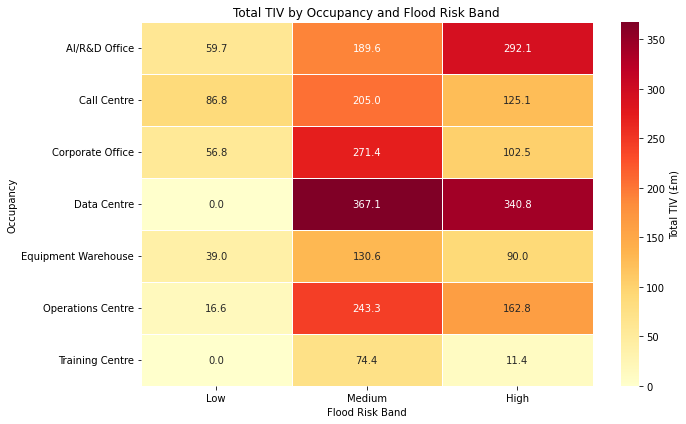

In [216]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tiv_heatmap = pd.pivot_table(
    sov,
    values="Total_TIV",
    index="Occupancy",
    columns="Flood_Risk_Band",
    aggfunc="sum",
    fill_value=0
)

# Order flood-risk categories
tiv_heatmap = tiv_heatmap.reindex(
    columns=["Low", "Medium", "High"]
)

# Convert to £ millions for readability
tiv_heatmap_m = tiv_heatmap / 1_000_000

plt.figure(figsize=(10, 6))

sns.heatmap(
    tiv_heatmap_m,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Total TIV (£m)"}
)

plt.title("Total TIV by Occupancy and Flood Risk Band")
plt.xlabel("Flood Risk Band")
plt.ylabel("Occupancy")
plt.tight_layout()
plt.show()

### Data Centre exposure is all concentrated in Medium and High flood-risk bands, with £707.9m of TIV across the two categories, making it the clearest occupancy–flood accumulation hotspot.

#### 10.13 Which individual High flood-risk locations have the largest Total_TIV?

In [91]:
sov.loc[sov["Flood_Risk_Band"]=="High"].sort_values("Total_TIV",ascending=False)

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep
76,LOC077,B077,Kingston upon Hull Data Centre 077,Data Centre,13 Enterprise Drive,Kingston upon Hull,East Riding of Yorkshire,HU16 6PN,High,Surface Water,...,OK,75,Local,No,Central,No,14.85,160650000,0,0
56,LOC057,B057,Leeds Data Centre 057,Data Centre,30 Trinity Way,Leeds,West Yorkshire,LS56 8HP,High,Rivers & Sea + Surface Water,...,OK,100,Local,No,Local,No,16.79,105100000,0,0
2,LOC003,B003,Kingston upon Hull Data Centre 003,Data Centre,26 Technology Drive,Kingston upon Hull,East Riding of Yorkshire,HU59 6FM,High,Rivers & Sea + Surface Water,...,ERROR,100,Central,No,None,No,33.33,75000000,0,3000000
39,LOC040,B040,Lincoln AI/R&D Office 040,AI/R&D Office,42 Enterprise Avenue,Lincoln,Lincolnshire,LN89 8KY,High,Rivers & Sea,...,OK,0,None,Yes,Local,No,10.66,36100000,0,0
5,LOC006,B006,Birmingham Operations Centre 006,Operations Centre,30 Trinity Drive,Birmingham,West Midlands,B99 6DK,High,Rivers & Sea + Surface Water,...,OK,100,Central,No,Central,No,17.15,35850000,0,0
40,LOC041,B041,Warrington AI/R&D Office 041,AI/R&D Office,93 Gateway Court,Warrington,Cheshire,WA81 8BG,High,Rivers & Sea + Surface Water,...,OK,75,None,Yes,Local,No,12.11,35100000,0,0
62,LOC063,B063,Peterborough AI/R&D Office 063,AI/R&D Office,81 Meridian Avenue,Peterborough,Cambridgeshire,PE74 7ZX,High,Rivers & Sea,...,OK,0,Local,Yes,Local,Yes,3.93,33050000,0,0
60,LOC061,B061,Warrington Equipment Warehouse 061,Equipment Warehouse,170 Parkside Court,Warrington,Cheshire,WA78 8PJ,High,Surface Water,...,OK,75,None,Yes,Local,No,4.17,31200000,0,0
37,LOC038,B038,Preston Equipment Warehouse 038,Equipment Warehouse,37 Mill Business Park,Preston,Lancashire,PR22 5WV,High,Surface Water,...,OK,100,Local,Yes,Local,No,7.72,30450000,0,0
49,LOC050,B050,Leeds AI/R&D Office 050,AI/R&D Office,70 Waterside Drive,Leeds,West Yorkshire,LS62 5LD,High,Rivers & Sea + Surface Water,...,OK,100,Central,Yes,Central,No,24.36,29350000,0,0


LOC077 has the largest TIV amongst high flood risk locations.

### 11. Address & Location Data Quality

#### 11.1 Postcode completeness

In [92]:
sov["Postcode"].isna().sum()

0

In [93]:
sov[sov["Postcode"]==""]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep


#### 11.2 Do all postcodes follow a plausible UK postcode format?

In [94]:
postcode_pattern = r"^[A-Z]{1,2}\d[A-Z\d]?\s\d[A-Z]{2}$"

sov[~sov["Postcode"].str.upper().str.match(postcode_pattern, na=False)]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep


All postcodes conform to the expected structural pattern.

### 12. CAT Modelling Attribute Scrubbing

#### 12.1 Construction Code Validation

In [95]:
sov["Construction_Code"].value_counts()

Steel Portal Frame     28
Masonry                20
Reinforced Concrete    19
Mixed Construction     16
Steel Frame            16
Name: Construction_Code, dtype: int64

The populated Construction_Code values are consistently formatted across the SOV, with five standardised descriptive categories and one missing value already identified.

#### 12.2 Construction Classification Review

On observing the 5 distinct construction classifications, Mixed Contruction seems insuffciently specific for model mapping and should be investigated further. Moreover, whether Steel Portal Frame and Steel Frame are equivalent descriptions should also be looked into. 

##### 12.2.1 Investigating Mixed Construction

In [103]:
sov.loc[sov["Construction_Code"]=="Mixed Construction",["Location_ID","Occupancy","Year_Built","Stories","Floor_Area_sqft","Total_TIV"]]

,Location_ID,Occupancy,Year_Built,Stories,Floor_Area_sqft,Total_TIV
0,LOC001,AI/R&D Office,1980.0,3,17000,20950000
8,LOC009,Call Centre,1972.0,3,22500,15350000
11,LOC012,Corporate Office,1981.0,8,17500,25350000
15,LOC016,Corporate Office,1997.0,5,13500,14550000
19,LOC020,Operations Centre,1972.0,4,23500,27750000
22,LOC023,Operations Centre,1994.0,4,9000,27950000
35,LOC036,Operations Centre,1974.0,5,11500,27500000
38,LOC039,Call Centre,1999.0,5,24000,22750000
57,LOC058,Corporate Office,1988.0,3,13000,18450000
64,LOC065,Corporate Office,1980.0,2,9500,13500000


The Mixed Construction category is used across diverse property characteristics and does not provide sufficient structural detail for a definitive CAT-modelling classification. Supporting construction information should be obtained before model mapping.

##### 12.2.3 Construction × Occupancy Cross-tab

In [118]:
pd.crosstab(sov["Construction_Code"],sov["Occupancy"], margins=True)

Occupancy,AI/R&D Office,Call Centre,Corporate Office,Data Centre,Equipment Warehouse,Operations Centre,Training Centre,All
Construction_Code,,,,,,,,
Masonry,4,7,0,1,4,2,2,20
Mixed Construction,2,3,5,0,0,6,0,16
Reinforced Concrete,4,4,6,2,1,0,2,19
Steel Frame,3,3,5,0,3,1,1,16
Steel Portal Frame,7,3,4,3,0,9,2,28
All,20,20,20,6,8,18,7,99


Steel Portal Frame is more concentrated in Operations Centres and AI/R&D Offices, while Steel Frame appears more frequently in Corporate Offices. However, these patterns alone are insufficient to determine whether the two source descriptions should map to the same construction classification.

#### 12.3 Year Built Validation

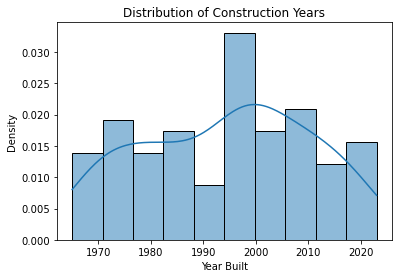

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

years = sov["Year_Built"].dropna()

sns.histplot(years, bins=10, stat="density", kde=True)

plt.xlabel("Year Built")
plt.ylabel("Density")
plt.title("Distribution of Construction Years")
plt.show()

Construction years show a concentration around the 1990–2000 period, indicating a relatively mature portfolio. Many locations are approximately 25–35 years old as of 2026.

#### 12.4 Stories Validation

In [122]:
sov["Stories"].value_counts().sort_index()

1     6
2    14
3    14
4    15
5    24
6    11
7    11
8     5
Name: Stories, dtype: int64

Story counts range from 1 to 8, with 5-storey properties being the most common. The distribution appears plausible, with no obvious anomalous values requiring remediation.

#### 12.5 Floor Area Validation

In [123]:
sov[sov["Floor_Area_sqft"]<=0]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep


In [124]:
sov["Floor_Area_sqft"].map(type).value_counts()

<class 'int'>    100
Name: Floor_Area_sqft, dtype: int64

All floor-area values are positive integers with no invalid or non-numeric records identified.

#### 12.6 — Secondary Risk Modifiers

##### 12.6.1 Are all sprinkler coverage values within the logical 0–100% range?

In [128]:
sov["Sprinkler_Coverage_Pct"].unique()

array([ 75,  50, 100,  25,   0,  90], dtype=int64)

All values lie between 0-100%.

##### 12.6.2 What unique values are present in Fire_Detection, and are they consistently coded? 

In [130]:
sov["Fire_Detection"].value_counts()

Local      37
None       33
Central    30
Name: Fire_Detection, dtype: int64

The field is complete and consistently coded.

##### 12.6.3 What values are present in Smoke_Detection, and are they consistently coded?

In [131]:
sov["Smoke_Detection"].value_counts()

No     56
Yes    44
Name: Smoke_Detection, dtype: int64

No missing or anomalies present.

##### 12.6.4 What values are present Burglar_Alarm, and are they consistently coded?

In [133]:
sov["Burglar_Alarm"].value_counts()

Central    35
None       33
Local      32
Name: Burglar_Alarm, dtype: int64

Burglar_Alarm has three consistently coded categories.

##### 12.6.5 What values are present in Vacant, and are they consistently coded?

In [134]:
sov["Vacant"].value_counts()

No     96
Yes     4
Name: Vacant, dtype: int64

96% of insured locations are not vacant.

##### 12.6.6 Modifier Review Conclusion 

The secondary risk modifier fields are complete and consistently coded. Sprinkler coverage values fall within the valid 0–100% range, while fire detection, smoke detection, burglar alarm and vacancy use consistent categorical values.

#### 12.7 Are there any locations with a non-positive number of stories OR a non-positive floor area?

In [136]:
sov.loc[(sov["Stories"]>0) & (sov["Floor_Area_sqft"]<=0)]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep


In [137]:
sov.loc[(sov["Stories"]<=0) & (sov["Floor_Area_sqft"]>0)]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,TIV_Check,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep


No logical inconsistency was identified between the presence of storeys and floor area.

#### 12.8 BI Share Reconciliation 

Does the reported BI_Share_of_TIV_Pct reconcile with BI_TIV / Total_TIV × 100 for every location?

In [142]:
sov["BI_share_check"]=round(sov["BI_Share_of_TIV_Pct"]-(sov["BI_TIV"] / sov["Total_TIV"] * 100),2)

In [143]:
sov.loc[sov["BI_share_check"]!=0]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep,BI_share_check


Each reported BI share of TIV reconciles with the corresponding calculated value obtained from the source data.

#### 12. 9 BI Share Validity

In [147]:
sov.loc[(sov["BI_Share_of_TIV_Pct"]<0) | (sov["BI_Share_of_TIV_Pct"]>100)]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,Sprinkler_Coverage_Pct,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep,BI_share_check


All BI_Share_of_TIV_Pct values within the logical 0–100% range.

### 13. QA Summary

In [161]:
location_id_check = sov["Location_ID"].nunique() == len(sov)

missing_value_check = missing_value_count == 0

tiv_component_check = (sov["TIV_check_cal"] == 0).all()

reported_tiv_check = (sov["TIV_check_rep"] == 0).all()

negative_tiv_check = not ((sov["Building_TIV"] <= 0) |
                         (sov["Contents_TIV"] <= 0) |
                         (sov["EDP_IT_TIV"] <= 0) |
                         (sov["BI_TIV"] <= 0)).any()

bi_share_check = (
    (sov["BI_Share_of_TIV_Pct"] >= 0) &
    (sov["BI_Share_of_TIV_Pct"] <= 100)
).all()

In [162]:
qa_summary = pd.DataFrame({
    "QA_Check": [
        "Location ID uniqueness",
        "Missing values",
        "TIV component reconciliation",
        "Reported vs calculated TIV",
        "Zero / negative TIV",
        "BI share validity"
    ],
    "Status": [
        "PASS" if location_id_check else "FAIL",
        "PASS" if missing_value_check else "FLAG",
        "PASS" if tiv_component_check else "FAIL",
        "PASS" if reported_tiv_check else "FLAG",
        "PASS" if negative_tiv_check else "FAIL",
        "PASS" if bi_share_check else "FAIL"
    ]
})

In [163]:
qa_summary

,QA_Check,Status
0,Location ID uniqueness,PASS
1,Missing values,FLAG
2,TIV component reconciliation,PASS
3,Reported vs calculated TIV,FLAG
4,Zero / negative TIV,PASS
5,BI share validity,PASS


### 13. Geographic enrichment

#### 13.1 Adding "Country" column

In [165]:
sov["Country"]="United Kingdom"

#### 13.2 Duplicate Postcodes

In [168]:
sov[sov.duplicated(subset=["Postcode"],keep=False)]

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep,BI_share_check,Country


#### 13.3 County-level TIV concentration

In [169]:
sov.groupby("County")["Total_TIV"].sum().sort_values(ascending=False)

County
West Midlands               407100000
East Riding of Yorkshire    315250000
West Yorkshire              263200000
Cheshire                    254450000
Lancashire                  213400000
Cambridgeshire              203250000
Devon                       163300000
Suffolk                     105300000
Somerset                    100550000
Essex                        97750000
North Yorkshire              90350000
Lincolnshire                 87050000
South Yorkshire              73800000
Derbyshire                   71700000
Berkshire                    71150000
Worcestershire               64450000
Greater Manchester           50300000
Nottinghamshire              44400000
Bristol                      44350000
Kent                         41600000
Greater London               40900000
Gloucestershire              22050000
Oxfordshire                  19750000
Norfolk                      19550000
Name: Total_TIV, dtype: int64

#### 13.4 Geographic concentration ratio

In [172]:
top_5_counties_tiv=sov.groupby("County")["Total_TIV"].sum().sort_values(ascending=False).head(5).sum()
top_5_counties_tiv

1453400000

In [173]:
top_5_counties_tiv_share=round(top_5_counties_tiv/portfolio_tiv*100,2)
top_5_counties_tiv_share

50.73

The five highest-exposure counties account for 50.73% of total portfolio TIV, indicating significant geographic concentration.

### 14. Final Pre-Model QA & Readiness Assessment

#### 14.1 Open Exceptions

In [203]:
missing_cells = sov[sov.isna().any(axis=1)]

open_exception_df = (
    missing_cells
    .set_index("Location_ID")
    .isna()
    .stack()
    .reset_index(name="Missing")
)

open_exception_df = open_exception_df[
    open_exception_df["Missing"]
].drop(columns="Missing")

In [204]:
open_exception_df

,Location_ID,level_1
11,LOC002,Year_Built
43,LOC056,Construction_Code


In [205]:
open_exception_df=open_exception_df.rename(columns={"level_1":"Field"})

In [206]:
open_exception_df["Issue"]="Missing Value"
open_exception_df["Action"]="Put On Hold"
open_exception_df["Status"]="Open"
open_exception_df

,Location_ID,Field,Issue,Action,Status
11,LOC002,Year_Built,Missing Value,Put On Hold,Open
43,LOC056,Construction_Code,Missing Value,Put On Hold,Open


In [207]:
tiv_check_records= sov.loc[sov["TIV_check_rep"]!=0]
tiv_check_records

,Location_ID,Building_ID,Building_Name,Occupancy,Address,City,County,Postcode,Flood_Risk_Band,Primary_Flood_Source,...,Fire_Detection,Smoke_Detection,Burglar_Alarm,Vacant,BI_Share_of_TIV_Pct,cal_TIV,TIV_check_cal,TIV_check_rep,BI_share_check,Country
2,LOC003,B003,Kingston upon Hull Data Centre 003,Data Centre,26 Technology Drive,Kingston upon Hull,East Riding of Yorkshire,HU59 6FM,High,Rivers & Sea + Surface Water,...,Central,No,None,No,33.33,75000000,0,3000000,-0.0,United Kingdom
72,LOC073,B073,Derby Training Centre 073,Training Centre,36 Quayside Drive,Derby,Derbyshire,DE61 3ZS,Medium,Rivers & Sea,...,None,Yes,Central,No,24.38,14150000,0,-500000,-0.0,United Kingdom


In [208]:
tiv_check_records= sov.loc[sov["TIV_check_rep"]!=0]
tiv_exceptions=pd.DataFrame({"Location_ID":tiv_check_records["Location_ID"].values, "Field":"Reported_Total_TIV","Issue":"TIV Reconciliation","Action":"Investigate","Status":"Open"})
tiv_exceptions

,Location_ID,Field,Issue,Action,Status
0,LOC003,Reported_Total_TIV,TIV Reconciliation,Investigate,Open
1,LOC073,Reported_Total_TIV,TIV Reconciliation,Investigate,Open


In [209]:
pd.concat([open_exception_df,tiv_exceptions],ignore_index=True)

,Location_ID,Field,Issue,Action,Status
0,LOC002,Year_Built,Missing Value,Put On Hold,Open
1,LOC056,Construction_Code,Missing Value,Put On Hold,Open
2,LOC003,Reported_Total_TIV,TIV Reconciliation,Investigate,Open
3,LOC073,Reported_Total_TIV,TIV Reconciliation,Investigate,Open


In [201]:
construction_exceptions=pd.DataFrame({"Field":"Construction_Code","Category":["Mixed Construction","Steel Portal Frame"],"Issue":["Insufficient Information","Similar to Steel Frame"],"Status":"Open"})
construction_exceptions

,Field,Category,Issue,Status
0,Construction_Code,Mixed Construction,Insufficient Information,Open
1,Construction_Code,Steel Portal Frame,Similar to Steel Frame,Open


### The SOV has passed the majority of structural, exposure-value and attribute validation checks. Six open issues remain: four location-level exceptions involving missing values or TIV reconciliation, and two construction-classification exceptions requiring further mapping validation. These issues should be resolved before the dataset is treated as fully model-ready.